In [170]:
# imports for building a knn model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from data_split import split_data
from backward_selection import backward_selected_knn
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer


In [171]:
#split feature engineered data into train val test
data = pd.read_csv('datasets/ny_hp_feature_engineered.csv')
#split_data(dataset, y, test_size, val_size, random_state)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(data, 'price', 0.2, 0.2, 42)

#drop log price
X_train = X_train.drop(columns=['price_log'])
X_val = X_val.drop(columns=['price_log'])
X_test = X_test.drop(columns=['price_log'])

#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#rejoin scaled data with y
train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train = pd.concat([train_scaled, y_train.reset_index(drop=True)], axis=1)  
val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
val = pd.concat([val_scaled, y_val.reset_index(drop=True)], axis=1)
test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
test = pd.concat([test_scaled, y_test.reset_index(drop=True)], axis=1)

#log transform price
train['price_log'] = np.log1p(train['price'])
log_y_train = train['price_log']
val['price_log'] = np.log1p(val['price'])
log_y_val = val['price_log']
test['price_log'] = np.log1p(test['price'])
log_y_test = test['price_log']

### all potential variables to consider based on EDA
* bathrooms
* rooms
* waterfront
* bedrooms
* land value
* living area
* new_construct 
* fuel tyope
* heat_type




### all potential interaction effects to consider
* living area $\times$ rooms
* land value $\times$ living area
* waterfront $\times$ land value
* living area $\times$ land value
* new_construct $\times$ fuel type
* new_construct $\times$ heat type


In [172]:
#interaction terms
X_train['interaction_1'] = X_train['living_area'] * X_train['rooms']
X_train['interaction_2'] = X_train['living_area'] * X_train['land_value']
X_train['interaction_3'] = X_train['waterfront'] * X_train['land_value']
X_train['interaction_4'] = X_train['living_area_log'] * X_train['rooms']
X_train['interaction_5'] = X_train['living_area_log'] * X_train['land_value_log']
X_train['interaction_6'] = X_train['waterfront'] * X_train['land_value_log']

X_val['interaction_1'] = X_val['living_area'] * X_val['rooms']
X_val['interaction_2'] = X_val['living_area'] * X_val['land_value']
X_val['interaction_3'] = X_val['waterfront'] * X_val['land_value']
X_val['interaction_4'] = X_val['living_area_log'] * X_val['rooms']
X_val['interaction_5'] = X_val['living_area_log'] * X_val['land_value_log']
X_val['interaction_6'] = X_val['waterfront'] * X_val['land_value_log']

X_test['interaction_1'] = X_test['living_area'] * X_test['rooms']
X_test['interaction_2'] = X_test['living_area'] * X_test['land_value']
X_test['interaction_3'] = X_test['waterfront'] * X_test['land_value']  
X_test['interaction_4'] = X_test['living_area_log'] * X_test['rooms']
X_test['interaction_5'] = X_test['living_area_log'] * X_test['land_value_log']
X_test['interaction_6'] = X_test['waterfront'] * X_test['land_value_log']    




In [173]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   lot_size             1105 non-null   float64
 1   waterfront           1105 non-null   float64
 2   age                  1105 non-null   float64
 3   land_value           1105 non-null   float64
 4   new_construct        1105 non-null   float64
 5   central_air          1105 non-null   float64
 6   living_area          1105 non-null   float64
 7   pct_college          1105 non-null   float64
 8   bedrooms             1105 non-null   float64
 9   fireplaces           1105 non-null   float64
 10  bathrooms            1105 non-null   float64
 11  rooms                1105 non-null   float64
 12  test                 1105 non-null   float64
 13  living_area_log      1105 non-null   float64
 14  land_value_log       1105 non-null   float64
 15  fuel_type_Gas        1105 non-null   f

## Variable Selection

In [174]:
## variable set 1
#backward_selected_knn(X_train, X_val, y_train, y_val, predictors, k)
predictors_1 = ['bathrooms', 'rooms', 'waterfront', 'living_area', 'land_value', 'new_construct', 'fuel_type_Gas', 'fuel_type_Oil', 'heat_type_Hot Air', 'heat_type_Hot Water']
backward_selected_knn(X_train, X_val, y_train, y_val, predictors_1, 10)


Initial RMSE with all listed predictors: 67369.1172
Removing land_value improved RMSE: 67369.1172 → 65212.3550
Removing rooms improved RMSE: 65212.3550 → 64902.8451
Removing heat_type_Hot Water improved RMSE: 64902.8451 → 64901.7829
Removing heat_type_Hot Air improved RMSE: 64901.7829 → 64825.3459
Removing fuel_type_Gas improved RMSE: 64825.3459 → 64747.7607
Removing new_construct improved RMSE: 64747.7607 → 64747.4729

 Final features: ['bathrooms', 'waterfront', 'living_area', 'fuel_type_Oil']
 Final validation RMSE: 64747.4729
 R²: 0.5469
 MAE: 43611.9032


['bathrooms', 'waterfront', 'living_area', 'fuel_type_Oil']

In [175]:
# variable set 1 with log price
ppredictors_1 = ['bathrooms', 'rooms', 'waterfront', 'living_area', 'land_value', 'new_construct', 'fuel_type_Gas', 'fuel_type_Oil', 'heat_type_Hot Air', 'heat_type_Hot Water']
backward_selected_knn(X_train, X_val, log_y_train, log_y_val, predictors_1, 10)

Initial RMSE with all listed predictors: 0.3904
Removing land_value improved RMSE: 0.3904 → 0.3797
Removing rooms improved RMSE: 0.3797 → 0.3760
Removing fuel_type_Oil improved RMSE: 0.3760 → 0.3759

 Final features: ['bathrooms', 'waterfront', 'living_area', 'new_construct', 'fuel_type_Gas', 'heat_type_Hot Air', 'heat_type_Hot Water']
 Final validation RMSE: 0.3759
 R²: 0.4217
 MAE: 0.2240


['bathrooms',
 'waterfront',
 'living_area',
 'new_construct',
 'fuel_type_Gas',
 'heat_type_Hot Air',
 'heat_type_Hot Water']

In [176]:
predictors_2 = ['bathrooms', 'rooms', 'waterfront', 'living_area_log', 'land_value_log', 'new_construct', 'fuel_type_Gas', 'fuel_type_Oil', 'heat_type_Hot Air', 'heat_type_Hot Water']
backward_selected_knn(X_train, X_val, y_train, y_val, predictors_2, 10)

Initial RMSE with all listed predictors: 64566.6998
Removing rooms improved RMSE: 64566.6998 → 59791.3606
Removing heat_type_Hot Air improved RMSE: 59791.3606 → 58960.5745
Removing heat_type_Hot Water improved RMSE: 58960.5745 → 58512.9551
Removing fuel_type_Gas improved RMSE: 58512.9551 → 57947.5091

 Final features: ['bathrooms', 'waterfront', 'living_area_log', 'land_value_log', 'new_construct', 'fuel_type_Oil']
 Final validation RMSE: 57947.5091
 R²: 0.6371
 MAE: 39117.8318


['bathrooms',
 'waterfront',
 'living_area_log',
 'land_value_log',
 'new_construct',
 'fuel_type_Oil']

In [177]:
predictors_3 = ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area', 'land_value', 'interaction_1', 'interaction_2', 'interaction_3']
backward_selected_knn(X_train, X_val, y_train, y_val, predictors_3, 10)

Initial RMSE with all listed predictors: 70695.6394
Removing interaction_2 improved RMSE: 70695.6394 → 61273.2847

 Final features: ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area', 'land_value', 'interaction_1', 'interaction_3']
 Final validation RMSE: 61273.2847
 R²: 0.5942
 MAE: 42873.1625


['bathrooms',
 'waterfront',
 'fuel_type_Oil',
 'new_construct',
 'living_area',
 'land_value',
 'interaction_1',
 'interaction_3']

In [178]:
predictors_4 = ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area_log', 'land_value_log', 'interaction_4', 'interaction_6']
backward_selected_knn(X_train, X_val, y_train, y_val, predictors_4, 10)

Initial RMSE with all listed predictors: 62754.6513
Removing interaction_4 improved RMSE: 62754.6513 → 58254.5206
Removing interaction_6 improved RMSE: 58254.5206 → 57947.5091

 Final features: ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area_log', 'land_value_log']
 Final validation RMSE: 57947.5091
 R²: 0.6371
 MAE: 39117.8318


['bathrooms',
 'waterfront',
 'fuel_type_Oil',
 'new_construct',
 'living_area_log',
 'land_value_log']

In [179]:
predictors_5 = ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area','land_value', 'central_air', 'interaction_4', 'interaction_6', 'age', 'pct_college', 'fireplaces', 'rooms', 'bedrooms']
backward_selected_knn(X_train, X_val, y_train, y_val, predictors_5, 10)
 

Initial RMSE with all listed predictors: 67386.4565
Removing land_value improved RMSE: 67386.4565 → 66399.0697
Removing age improved RMSE: 66399.0697 → 64845.9450
Removing interaction_4 improved RMSE: 64845.9450 → 63922.4664
Removing fireplaces improved RMSE: 63922.4664 → 63838.5340
Removing bathrooms improved RMSE: 63838.5340 → 63836.5981

 Final features: ['waterfront', 'fuel_type_Oil', 'new_construct', 'living_area', 'central_air', 'interaction_6', 'pct_college', 'rooms', 'bedrooms']
 Final validation RMSE: 63836.5981
 R²: 0.5595
 MAE: 43471.6357


['waterfront',
 'fuel_type_Oil',
 'new_construct',
 'living_area',
 'central_air',
 'interaction_6',
 'pct_college',
 'rooms',
 'bedrooms']

### Final KNN Model


In [180]:
predictors = ['bathrooms', 'waterfront', 'fuel_type_Oil', 'new_construct', 'living_area_log', 'land_value_log']

In [181]:
## choodsing best model

neighbours=np.arange(1, 101)
best_score = -np.inf
    
for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors = k, metric='euclidean') 
    scores = cross_val_score(knn, X_train[predictors], y_train, 
                             cv=20, scoring = 'neg_mean_squared_error')
    # taking the average of scores across 20 folds
    cv_score = np.mean(scores)
     # use the cv score for model selection
    if cv_score >= best_score:
        best_score = cv_score
        best_knn = knn
    
knn = best_knn
knn.fit(X_train[predictors], y_train)


predictions = knn.predict(X_val[predictors])
val_rmse = np.sqrt(mean_squared_error(y_val, predictions))
cv_rmse= np.sqrt(-best_score)
print('Chosen K: {}'.format(knn.n_neighbors))
print('Validation RMSE:', val_rmse) 
print('CV RMSE:', cv_rmse)

Chosen K: 16
Validation RMSE: 59816.21127474597
CV RMSE: 60548.88138245636


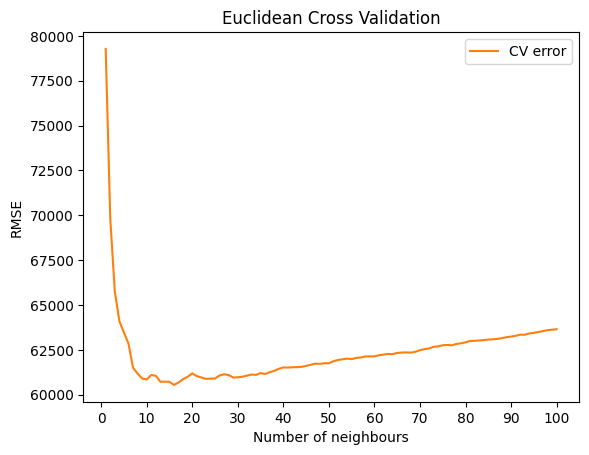

In [182]:
cv_rmse = []

for k in neighbours: 
    knn = KNeighborsRegressor(n_neighbors = k, metric='euclidean') 
    scores = cross_val_score(knn, X_train[predictors], y_train, cv=20, scoring = 'neg_mean_squared_error')
    rmse = np.sqrt(-1*np.mean(scores)) 
    cv_rmse.append(rmse)
    knn.fit(X_train[predictors], y_train)

fig, ax= plt.subplots()
ax.plot(neighbours, cv_rmse, color='#FF7F0E', label='CV error')
ax.set_xlabel('Number of neighbours')
ax.set_xticks(np.arange(0, 101, 10))
ax.set_ylabel('RMSE')
ax.set_title('Euclidean Cross Validation')
plt.legend()
plt.savefig('plots/ Euclidean_CV_(KNN)')
plt.show()

In [184]:
## test the model with test data

knn = KNeighborsRegressor(n_neighbors=15, metric='euclidean')
knn.fit(X_test[predictors], y_test)
predictions = knn.predict(X_test[predictors])

final_rmse = np.sqrt(mean_squared_error(y_test, predictions))
final_rsquared = r2_score(y_test, predictions)
final_mae = mean_absolute_error(y_test, predictions)

print(f" Final validation RMSE: {final_rmse:.4f}")
print(f" R²: {final_rsquared:.4f}")
print(f" MAE: {final_mae:.4f}")

 Final validation RMSE: 69868.6558
 R²: 0.5837
 MAE: 46427.3089
